# 🚀 Introduction to Machine Learning: Fundamental Models

## Course Overview

Welcome! This is a comprehensive, educator-focused Jupyter Notebook for teaching fundamental machine learning algorithms. Each section is **self-contained** with its own imports, data loading, and extensive explanations designed for student understanding.

### Pedagogical Approach
- **Self-contained sections**: Each model has everything it needs
- **Theory first**: Understand the 'what' and 'why' before code
- **Extensive explanations**: For deep understanding, not just syntax
- **Real-world context**: When and why to use each algorithm

# 🔄 Step 1: Data Preprocessing & Train-Test Split

## Why Data Preprocessing Matters

Before training any ML model, proper data preparation is essential. This typically comprises **60-80% of any machine learning project**. High-quality preprocessing directly impacts model performance more than the choice of algorithm!

### The Data Preparation Pipeline

```
Raw Data → Exploration → Cleaning → Feature Scaling → Train-Test Split → Ready for Modeling
   ↓         (EDA)        (Quality)    (Normalization)    (Validation)
 Messy,    Understand    Handle        Bring to similar   Fair
 Unknown   patterns      issues        scale              evaluation
```

---

## 📊 Part 1: Comprehensive Data Preparation & Cleaning

### 1. **Data Loading & Exploration (Exploratory Data Analysis - EDA)**

Before modifying data, **understand what you have**:

**Key Questions to Ask:**
- **Size**: How many rows (samples) and columns (features)?
- **Types**: Are columns numerical, categorical, text, or datetime?
- **Missing Values**: Are there NaN or null values? How many in each column?
- **Duplicates**: Are there exact duplicate rows or near-duplicates?
- **Statistics**: Mean, median, std, min, max for numerical features
- **Distribution**: Is data normally distributed or skewed?
- **Class Balance**: For classification, are classes balanced or imbalanced?
- **Correlations**: Which features are strongly related to each other?
- **Outliers**: Are there extreme values that seem unusual?

**Why This Matters**:
- You can't fix problems you don't know exist
- Bad data quality → Unreliable models
- Patterns found here inform cleaning strategy

**Example**: A student age dataset might reveal:
- Ages from 18-85 (outliers? Or real data?)
- 5% missing values in phone column
- Classes: 80% undergrad, 20% grad (imbalanced!)
- Strong correlation between GPA and graduation rate

---

### 2. **Data Cleaning**

Address data quality issues discovered in EDA:

#### **Missing Values Strategy**
Different approaches for different situations:

- **Few Missing Values (< 5%)**:
  - Drop rows (simple but loses data)
  - **Example**: Only 2 out of 1000 rows have missing email → drop them
  
- **Numerical Features with Missing Values**:
  - Impute with **mean** (average value)
  - Impute with **median** (less affected by outliers)
  - Forward fill / backward fill (for time series)
  - **Example**: Replace missing ages with average age of dataset
  
- **Categorical Features with Missing Values**:
  - Impute with **mode** (most frequent category)
  - Create "Unknown" category
  - **Example**: Missing region → assign "Unknown" or most common region
  
- **Advanced Imputation**:
  - K-Nearest Neighbors: Use similar samples' values
  - Multiple imputation: Create multiple plausible datasets
  - Domain knowledge: Use business rules
  - **When to use**: Large percentage missing, important feature

#### **Outlier Detection & Treatment**

Identify extreme values that don't fit the pattern:

- **Statistical Methods**:
  - Z-score > 3: Likely outlier
  - IQR (Interquartile Range): Values beyond 1.5 × IQR are outliers
  - **Example**: Height = 250 cm (impossible for humans → outlier)
  
- **Treatment Options**:
  - **Remove**: If clearly errors (height = -100)
  - **Cap**: Replace with 95th/99th percentile
  - **Keep**: Sometimes outliers are real and important!
  - **Separate**: Model outliers separately
  - **Decision Context**: Domain knowledge required
  
- **Model Impact**:
  - Linear models: Very sensitive to outliers (affected by coefficients)
  - Tree models: Robust to outliers (split-based, invariant)
  - Neural networks: Sensitive (gradient-based)

#### **Duplicate Rows**

- **Exact Duplicates**: Delete completely
  - **Example**: Same customer ID, same purchase twice
  
- **Near-Duplicates**: Investigate and merge
  - **Example**: Slightly different spelling of same address
  - Use fuzzy matching to identify
  
- **Intentional Duplicates**: Keep
  - **Example**: Multiple transactions from same customer (legitimate)

#### **Data Inconsistencies**

- **Typos in Categorical Variables**: Standardize
  - "USA", "U.S.A", "United States" → standardize to "USA"
  
- **Date Format Issues**: Convert to standard format
  - "12/31/2023", "2023-12-31", "31 Dec 2023" → ISO format: 2023-12-31
  
- **Unit Inconsistencies**: Convert to standard units
  - Prices in mixed currencies → convert to USD
  - Heights in mixed units (cm, inches) → convert to cm

---

### 3. **Feature Engineering & Selection**

Transform raw data into meaningful features that algorithms can learn from:

#### **Feature Creation**
Combine existing features meaningfully:
- **From Dates**: Extract year, month, day, day-of-week, is_weekend
  - **Why**: Algorithms don't understand dates; extract temporal patterns
- **From Numerical**: Create ratios, products, polynomials
  - **Example**: Revenue/Cost = Profit margin; Age² for non-linear relationships
- **From Categorical**: Create binary indicators
  - **Example**: "Has_email" (1 if email present, 0 otherwise)
- **Domain-Specific**: Use business knowledge
  - **Example**: In e-commerce: Cart_items/Cart_value = average item price

#### **Encoding Categorical Variables**
Algorithms need numbers, not text. Three main approaches:

- **One-Hot Encoding** (most common):
  - Create binary column for each category
  - **Example**: Color (Red, Blue, Green) → Color_Red (0/1), Color_Blue (0/1), Color_Green (0/1)
  - **Use**: When categories are non-ordinal, <100 categories
  - **Warning**: Creates many columns (curse of dimensionality)

- **Label Encoding**:
  - Map each category to a unique number: Red=0, Blue=1, Green=2
  - **Use**: Tree-based models (don't interpret numeric distance)
  - **Warning**: Linear models might interpret ordering that doesn't exist

- **Ordinal Encoding** (for ordered categories):
  - Preserve natural order: Small=1, Medium=2, Large=3
  - **Example**: Education level (HS=1, Bachelor=2, Master=3, PhD=4)
  - **Use**: When categories have natural ordering

#### **Feature Selection**
Remove irrelevant or redundant features:

- **Remove Low Variance Features**:
  - Features with same value across 95%+ of data contain no info
  - **Example**: Feature "IsHuman" is always 1 (useless)
  
- **Remove Highly Correlated Features**:
  - Correlation > 0.95: Likely redundant information
  - **Example**: Height and Shoe_Size highly correlated → keep one
  - **Reason**: Reduces multicollinearity, improves interpretability
  
- **Remove Missing Data Features**:
  - Drop columns with >90% missing values
  - **Reason**: Can't impute reliably
  
- **Statistical Methods**:
  - Correlation with target
  - Mutual information
  - Recursive feature elimination
  - **Why**: Focus on features most related to prediction task

**Why Feature Engineering Matters**:
- Good features → Better model performance
- Too many features → Overfitting, slow training, high cost
- Bad features → Model learns spurious patterns
- Right features → Smaller, faster, more interpretable models

---

### 4. **Feature Scaling / Normalization**

Bring all features to similar scale so no single feature dominates:

#### **Why Scaling Matters**

Different algorithms have different needs:

| Algorithm | Needs Scaling? | Why |
|-----------|----------------|-----|
| Linear Regression | Yes | Coefficients depend on scale |
| Logistic Regression | Yes | Gradient descent converges faster |
| SVM | **YES** (Critical!) | Distance-based; large values dominate |
| Decision Tree | No | Tree splits don't care about scale |
| Random Forest | No | Ensemble of splits invariant to scale |
| Neural Networks | **YES** (Important!) | Faster convergence, better performance |
| XGBoost | Somewhat | Helps but not critical |

#### **Common Scaling Methods**

1. **StandardScaler** (Most Common):
   - Formula: (x - mean) / standard_deviation
   - Result: Mean = 0, Std = 1 (bell curve centered at 0)
   - **Use**: Default choice for most algorithms
   - **Advantage**: Mathematically elegant, works well for normally distributed data

2. **MinMaxScaler** (Range 0-1):
   - Formula: (x - min) / (max - min)
   - Result: All values between 0 and 1
   - **Use**: When you need bounded values (e.g., probabilities)
   - **Downside**: Sensitive to outliers (one extreme value stretches scale)

3. **RobustScaler** (Robust to Outliers):
   - Formula: (x - median) / IQR
   - Result: Robust to extreme values
   - **Use**: When data has many outliers
   - **Advantage**: Outliers don't distort the scale

#### **Critical Rule**: Fit on Training Data ONLY!

⚠️ **WRONG Way**:
```
1. Fit scaler on FULL dataset (training + test)
2. Split into train/test
3. Train model on scaled training data
4. Evaluate on scaled test data
Result: Data leakage! Test set influenced the scaling!
```

✅ **CORRECT Way**:
```
1. Split into train/test
2. Fit scaler on TRAINING data only
3. Apply same scaler to test data
4. Train model on scaled training data
5. Evaluate on scaled test data
Result: Fair evaluation! Test set truly unseen!
```

---

### 5. **Handling Class Imbalance** (for Classification Tasks)

When one class vastly outnumbers others, models learn poorly:

**The Problem**:
- **Dataset**: 99% class 0, 1% class 1
- **Naive Model**: "Always predict class 0"
- **Accuracy**: 99% (misleading! Model predicts nothing useful)
- **But**: F1-score ≈ 0% (model never predicts class 1)

**Why It Happens**:
- Models optimize for accuracy by default
- Easy to get high accuracy by ignoring minority class
- Real-world example: Fraud detection (99.9% normal, 0.1% fraud)

**Solutions** (from simple to advanced):

1. **Simple: Oversampling** (duplicate minority class)
   - Duplicate minority examples until balanced
   - **Pro**: More data to train on
   - **Con**: Risk of overfitting minority class

2. **Simple: Undersampling** (remove majority class)
   - Remove majority examples until balanced
   - **Pro**: Faster training
   - **Con**: Lose data from majority class

3. **Moderate: SMOTE** (Synthetic Minority Over-sampling)
   - Create synthetic examples between existing minority points
   - **Pro**: Doesn't just duplicate; generates new examples
   - **Con**: Slightly more complex

4. **Advanced: Weighted Classes**
   - Give higher penalty for misclassifying minority class
   - **Example**: If Class 1 is 1% of data, weight it 100x higher
   - **Pro**: Uses all data, automatic in most sklearn models

5. **Advanced: Adjust Decision Threshold**
   - Default: Predict class 1 if probability > 0.5
   - For imbalanced: Lower threshold (e.g., > 0.3) to predict more class 1s
   - **Pro**: Fine-tune precision vs recall tradeoff

### Key Preprocessing Steps
1. **Data Exploration**: Understand data shape, types, and distributions
2. **Cleaning**: Handle missing values, outliers, and anomalies
3. **Feature Engineering**: Create and select meaningful features
4. **Feature Scaling**: Normalize/standardize features to similar scales
5. **Handle Imbalance**: Address class imbalance if present
6. **Train-Test Split**: Divide data for fair and unbiased evaluation

## The Fundamental Train-Test Split Principle

### The Critical Rule: NEVER evaluate on training data!

**Why?** If you test a model on the data it learned from:
- The model **memorizes** training data (overfitting)
- Performance metrics become **unrealistically optimistic**
- Real-world performance will be **dramatically worse**
- You lose trust in model generalization ability

### The 80-20 Split Solution

```
Original Data (100%)
    ↓
    ├─→ Training Set (80%): Used to adjust model parameters
    └─→ Test Set (20%):     Used to evaluate on unseen examples
```

### Why This Works
- **Training set**: Model learns patterns from these examples
- **Test set**: Completely unseen data that truly tests generalization
- **Fair comparison**: Different models compared on same test data
- **Realistic performance**: Reflects how model will perform in production

In [2]:
# Basic imports that all models will use
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Core visualization and data libraries imported")

✅ Core visualization and data libraries imported


---
# 📈 Step 2: Understanding Model Evaluation Metrics

## Critical Concept: Different Problems Need Different Metrics

Before building any model, you must understand how to measure its performance. **Using the wrong metric can lead to poor business outcomes**, even if the model seems "accurate."

---

## REGRESSION METRICS (Predicting Continuous Values)

When your target is a continuous number (house price, temperature, weight, etc.):

### Mean Squared Error (MSE)
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

**What it measures**: Average of squared differences between actual and predicted values
- **Lower is better** (0 = perfect predictions)
- **Advantage**: Penalizes large errors heavily (squaring makes big mistakes worse)
- **Disadvantage**: Units are squared (if predicting prices in dollars, MSE is in dollars²)

**Example**: MSE = 0.55 means average squared error is 0.55

### Root Mean Squared Error (RMSE)
$$RMSE = \sqrt{MSE}$$

**What it measures**: Square root of MSE
- **Lower is better**
- **Advantage**: Same units as original target (much more interpretable!)
- **Easier communication**: "Our model is off by $50k on average" vs "MSE is 2.5 billion"

**Example**: If RMSE = 0.74 for house prices in $100k units, actual error is ~$74k

### R² Score (Coefficient of Determination)
$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

**What it measures**: Proportion of variance in target explained by model
- **Range**: 0 to 1 (higher is better)
- **Interpretation**: R² = 0.85 means "model explains 85% of price variation, 15% due to unmeasured factors"
- **Business value**: Easy to explain to non-technical stakeholders

**Example interpretations**:
- R² = 0.95: Excellent! Model captures almost all variation
- R² = 0.70: Good. Captures most variation, but some factors missing
- R² = 0.40: Fair. Basic model, missing important patterns
- R² < 0: Worse than just predicting mean (model is useless)

---

## CLASSIFICATION METRICS (Predicting Categories)

When your target is a category (yes/no, spam/not spam, disease present/absent, etc.):

### The Confusion Matrix Foundation

All classification metrics are built from understanding four outcomes:

```
                        Predicted Positive | Predicted Negative
Actual Positive    |    TP (True Pos)     | FN (False Neg)
Actual Negative    |    FP (False Pos)    | TN (True Neg)
```

**Real-world example (Disease Detection)**:
- **TP**: Patient has disease, we predict "has disease" ✓ Correct!
- **FN**: Patient has disease, we predict "healthy" ✗ DANGEROUS! (missed sick patient)
- **FP**: Patient is healthy, we predict "has disease" ✗ Not ideal (unnecessary treatment)
- **TN**: Patient is healthy, we predict "healthy" ✓ Correct!

### Accuracy
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

**What it measures**: Percentage of correct predictions overall
- **Range**: 0-1 (higher is better, 1.0 = perfect)
- **Simple to understand**: "Model is correct 95% of the time"

**⚠️ MAJOR WARNING**: Accuracy can be MISLEADING with imbalanced data!

**Example of deception**:
- Dataset: 99% disease-free, 1% has disease
- Dumb model: Always predict "disease-free"
- Result: 99% accuracy! But completely useless (misses all sick patients)

**Lesson**: Use accuracy ONLY when classes are balanced

### Precision
$$Precision = \frac{TP}{TP + FP}$$

**What it measures**: "Of all positive predictions we made, how many were actually correct?"

**In plain English**: "When our model says 'positive', how often is it right?"

**When to optimize for**:
- Email spam detection: Don't want to flag legitimate emails as spam (FP is costly)
- Medical: Avoid unnecessary treatment of healthy people
- Criminal justice: Avoid wrongful accusations

**Example**: Precision = 0.90 means "When we say email is spam, we're correct 90% of the time"

### Recall
$$Recall = \frac{TP}{TP + FN}$$

**What it measures**: "Of all actual positives in data, how many did we find?"

**In plain English**: "Did we catch all the positive cases?"

**When to optimize for**:
- Disease detection: MUST catch all sick patients (FN is very costly - death!)
- Fraud detection: Must catch most fraudulent transactions
- Security: Must detect intrusions (missing attacks is worse than false alarms)

**Example**: Recall = 0.95 means "We correctly identify 95% of all disease cases"

### F1-Score
$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

**What it measures**: Harmonic mean of precision and recall
- **Range**: 0-1 (higher is better)
- **Use when**: You want balanced precision and recall
- **Advantage**: Good for imbalanced datasets (punishes if you ignore one class)

**Example**: F1 = 0.92 means good balance between finding positives and avoiding false positives

### ROC-AUC (Area Under ROC Curve)

**What it measures**: Probability that model ranks a random positive example higher than a random negative
- **Range**: 0 to 1 (0.5 = random guessing, 1.0 = perfect)
- **Advantage**: Works well with imbalanced data, threshold-independent
- **Interpretation**: "If we randomly pick one positive and one negative, model correctly ranks positive 92% of the time"

**Ranking ability**: Most comprehensive measure of model discrimination

---

## DECISION TABLE: Which Metric to Use When?

| Problem Type | Primary Metric | Secondary Metrics | Why This Choice? |
|---|---|---|---|
| **House price prediction** | RMSE or R² | MAE | Interpretable in dollars; easy to explain to client |
| **Email spam detection** | Precision | Recall | Don't flag legitimate emails (false positives costly) |
| **Disease detection** | Recall | Precision | Must catch sick patients (false negatives deadly) |
| **Imbalanced classification** | F1 or ROC-AUC | Precision/Recall | Accuracy misleading with class imbalance |
| **Binary balanced data** | Accuracy | F1, ROC-AUC | Simple and interpretable |
| **Competition scoring** | Depends on problem | ROC-AUC | Check competition definition |

---

### KEY PRINCIPLE FOR STUDENTS

**Always ask first**: "What would be the cost of different types of errors?"

This determines which metric matters most:
- False positive expensive? → Optimize Precision
- False negative expensive? → Optimize Recall
- Both equally bad? → Use F1
- Continuous values? → Use RMSE/R²

---
# 📊 Step 3: Linear Regression

## What is Linear Regression?

**Linear Regression** is the simplest and most fundamental supervised learning algorithm. It models relationships between input features and a continuous target variable using a linear equation.

### The Model Equation
$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n$$

Where:
- $\hat{y}$: Predicted value
- $\beta_0$: **Intercept** (the base/starting value when all features are 0)
- $\beta_1, \beta_2, ..., \beta_n$: **Coefficients** (weights showing how much each feature impacts the prediction)
- $x_1, x_2, ..., x_n$: Input features

### Intuitive Explanation

Imagine you're predicting house prices:
- Start with a base price (intercept): $100,000

- Each square foot adds: +$200 per sq ft

- Each bedroom adds: +$50,000

- Age subtracts: -$1,000 per year

- **Final prediction**: $100,000 + (sq_ft × $200) + (bedrooms × $50,000) - (age × $1,000)

### How It Works (Training Process)

1. **Initialize**: Start with random coefficients
2. **Make Predictions**: Calculate $\hat{y} = Xw$ for all training data
3. **Calculate Error**: Compute MSE (how far predictions are from actual)
4. **Optimize**: Use mathematics (calculus/least squares) to find coefficients that minimize error
5. **Result**: Final equation that best fits the data

### When to Use Linear Regression

**✅ Good for**:
- Continuous target variables (prices, temperatures, scores)
- Roughly linear relationships between features and target
- When interpretability is crucial (can explain each coefficient)
- Quick baseline models (something to beat)
- Small to moderate datasets

**❌ NOT good for**:
- Highly non-linear relationships
- Data with many outliers (linear regression is sensitive)
- Complex patterns that need non-linear models
- Classification problems (use Logistic Regression instead)

### Advantages
- ✓ Simple and interpretable (can explain coefficient impact)
- ✓ Fast to train and predict
- ✓ Works well when relationship is actually linear
- ✓ Good baseline for comparison
- ✓ Scalable to large datasets
- ✓ Mathematically well-understood

### Disadvantages
- ✗ Assumes linear relationship (may be wrong)
- ✗ Sensitive to outliers
- ✗ Cannot capture complex non-linear patterns
- ✗ Coefficients hard to interpret with correlated features
- ✗ Feature scaling affects coefficient interpretability

### Real-World Applications
- Real estate: Predicting house prices from features
- Agriculture: Crop yield prediction from rainfall, temperature
- Economics: Salary prediction from years of experience
- Medicine: Drug dosage response from patient characteristics

### Problem Description

In this problem, we aim to predict housing prices using several characteristics of each geographic area.

**Input (Features):**  
The model uses the following variables as predictors:

- **MedInc** – Median income of households in the area  
- **HouseAge** – Median age of houses  
- **AveRooms** – Average number of rooms per household  
- **AveBedrms** – Average number of bedrooms per household  
- **Population** – Total population in the block group  
- **AveOccup** – Average number of people per household (average occupancy)  
- **Latitude** – Geographic latitude of the area  
- **Longitude** – Geographic longitude of the area  

**Output (Target):**  
- **Median House Value** – The median house price in the area (measured in units of \$100,000).

The goal is to train a model that learns the relationship between the input features and the housing price, and then use the model to predict housing values for new areas.

In [1]:
# LINEAR REGRESSION - Self-contained section
# Each model imports what it needs
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
print("="*70)
print("LINEAR REGRESSION - California Housing Price Prediction")
print("="*70)

# Load regression dataset
print("\n📦 STEP 1: Load and Explore Data")
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target, name='price')
print(f"   Dataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"   Target range: ${y.min()*100:.0f}k - ${y.max()*100:.0f}k")

LINEAR REGRESSION - California Housing Price Prediction

📦 STEP 1: Load and Explore Data
   Dataset: 20640 samples, 8 features
   Target range: $15k - $500k


In [4]:
# Scale features
print("\n🔧 STEP 2: Feature Scaling (StandardScaler)")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print("   Features normalized to mean=0, std=1")

# Train-test split
print("\n✂️ STEP 3: Train-Test Split")
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f"   Training: {len(X_train)} samples (80%)")
print(f"   Testing:  {len(X_test)} samples (20%)")


🔧 STEP 2: Feature Scaling (StandardScaler)
   Features normalized to mean=0, std=1

✂️ STEP 3: Train-Test Split
   Training: 16512 samples (80%)
   Testing:  4128 samples (20%)


In [5]:
print("\n🤖 STEP 4: Create and Train Model")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("   ✓ Model trained using Least Squares optimization")

print("\n🔮 STEP 5: Make Predictions")
y_pred_train = lr_model.predict(X_train)
y_pred_test = lr_model.predict(X_test)
print(f"   ✓ Predictions made on {len(X_test)} test samples")


🤖 STEP 4: Create and Train Model
   ✓ Model trained using Least Squares optimization

🔮 STEP 5: Make Predictions
   ✓ Predictions made on 4128 test samples


In [6]:
print("\n📊 STEP 6: Evaluate Model Performance")
train_mse = mean_squared_error(y_train, y_pred_train)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_pred_train)

test_mse = mean_squared_error(y_test, y_pred_test)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred_test)

print("\n   Training Set Metrics:")
print(f"      MSE:  {train_mse:.4f}")
print(f"      RMSE: ${train_rmse*100:.1f}k (average error)")
print(f"      R²:   {train_r2:.4f} (explains {train_r2*100:.1f}% of variance)")

print("\n   Test Set Metrics:")
print(f"      MSE:  {test_mse:.4f}")
print(f"      RMSE: ${test_rmse*100:.1f}k (average error on unseen data)")
print(f"      R²:   {test_r2:.4f} (explains {test_r2*100:.1f}% of variance)")

print("\n💡 Interpretation:")
print(f"   The model explains {test_r2*100:.1f}% of house price variation")
print(f"   On average, predictions are off by ${test_rmse*100:.1f}k")
print(f"   Train-Test Gap: {(train_rmse - test_rmse)*100:.1f}k")
if abs(train_rmse - test_rmse) < test_rmse * 0.1:
    print(f"   ✓ Small gap = good generalization (not overfitting)")
else:
    print(f"   ⚠ Large gap = possible overfitting")

lr_results = {'Model': 'Linear Regression', 'Test_RMSE': test_rmse, 'Test_R2': test_r2}
print("\n✅ Linear Regression complete!")


📊 STEP 6: Evaluate Model Performance

   Training Set Metrics:
      MSE:  0.5179
      RMSE: $72.0k (average error)
      R²:   0.6126 (explains 61.3% of variance)

   Test Set Metrics:
      MSE:  0.5559
      RMSE: $74.6k (average error on unseen data)
      R²:   0.5758 (explains 57.6% of variance)

💡 Interpretation:
   The model explains 57.6% of house price variation
   On average, predictions are off by $74.6k
   Train-Test Gap: -2.6k
   ✓ Small gap = good generalization (not overfitting)

✅ Linear Regression complete!



📈 (Optional) STEP 7: Visualize Predicted vs True House Values


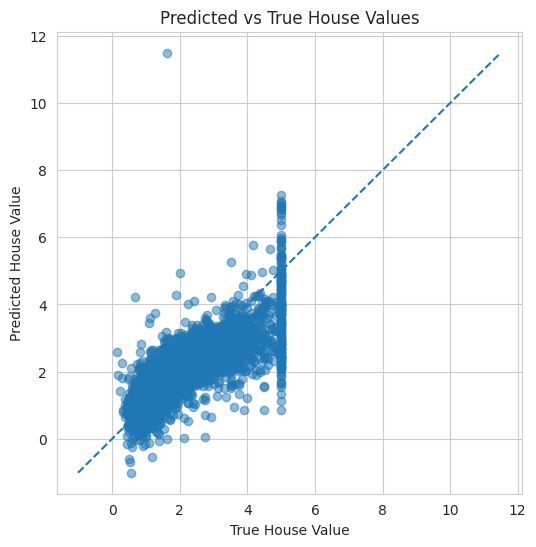

In [7]:
print("\n📈 (Optional) STEP 7: Visualize Predicted vs True House Values")
plt.figure(figsize=(6,6))

# Scatter plot of true vs predicted values
plt.scatter(y_test, y_pred_test, alpha=0.5)

# 45-degree reference line (perfect prediction)
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("True House Value")
plt.ylabel("Predicted House Value")
plt.title("Predicted vs True House Values")

plt.show()

---
# 📊 Step 4: Logistic Regression

## What is Logistic Regression?

Despite its name, **Logistic Regression is a CLASSIFICATION algorithm**, not regression! It predicts the probability that a sample belongs to a particular class.

### Key Differences from Linear Regression

| Aspect | Linear Regression | Logistic Regression |
|--------|-------------------|---------------------|
| **Task** | Regression (continuous) | Classification (categories) |
| **Output** | Any real number (-∞ to +∞) | Probability (0 to 1) |
| **Function** | Linear equation | Sigmoid (S-curve) |
| **Decision** | Direct prediction | Threshold at 0.5 |
| **Loss Function** | MSE | Cross-entropy |

### The Sigmoid Function (The Key Innovation)

$$P(y=1|x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + ...)}}$$

This **sigmoid function**:
- Takes any real number input and outputs between 0 and 1
- Creates smooth S-shaped curve
- Naturally represents probabilities
- More gradual than hard cutoff

### How Predictions Are Made

1. Calculate probability: $P(y=1|x) = \sigma(z)$ where $z = \beta_0 + \beta_1 x_1 + ...$
2. Apply threshold (usually 0.5):
   - If P > 0.5 → **predict class 1**
   - If P ≤ 0.5 → **predict class 0**

**Flexibility**: You can change threshold:
- Stricter (e.g., 0.7): Fewer false positives, more false negatives
- Lenient (e.g., 0.3): More false positives, fewer false negatives

### When to Use Logistic Regression

**✅ Good for**:
- Binary classification (yes/no, spam/not spam, disease/healthy)
- When probability estimates are important (not just binary prediction)
- Maximum interpretability (each coefficient has clear meaning)
- Baseline model for classification problems
- Linear decision boundaries
- Fast training and predictions

**❌ NOT good for**:
- Non-linear decision boundaries
- Complex interactions between features
- Multi-class without modifications (need One-vs-Rest)
- Feature scaling affects performance

### Advantages
- ✓ Produces probability estimates (not just classes)
- ✓ Highly interpretable coefficients
- ✓ Fast to train and predict
- ✓ Works well for binary classification
- ✓ Good baseline model
- ✓ Can be extended to multi-class

### Disadvantages
- ✗ Assumes linear decision boundary (limited flexibility)
- ✗ Cannot capture complex non-linear relationships
- ✗ Sensitive to feature scaling
- ✗ May underfit on complex datasets
- ✗ Requires careful threshold tuning for imbalanced data

### Real-World Applications
- Email classification: Spam vs. Not Spam
- Medical diagnosis: Disease Present vs. Absent (with probability)
- Credit scoring: Loan Default vs. No Default
- Marketing: Customer Will Buy vs. Won't Buy
- Cybersecurity: Intrusion Detected vs. Normal Traffic

### Problem Description

In this problem, we aim to predict whether a breast tumor is **malignant (cancerous)** or **benign (non-cancerous)** based on characteristics computed from digitized images of a fine needle aspirate (FNA) of a breast mass.

**Input (Features):**  
The model uses several numerical features describing properties of the cell nuclei in the image, including:

- **Radius** – Mean distance from the center to points on the cell boundary  
- **Texture** – Standard deviation of gray-scale values  
- **Perimeter** – Length of the cell boundary  
- **Area** – Area of the cell nucleus  
- **Smoothness** – Variation in radius lengths  
- **Compactness** – Measure of how compact the shape is  
- **Concavity** – Severity of concave portions of the contour  
- **Concave Points** – Number of concave portions of the contour  
- **Symmetry** – Symmetry of the cell nucleus  
- **Fractal Dimension** – Complexity of the boundary

These measurements are summarized using statistics such as **mean**, **standard error**, and **worst (largest)** values, resulting in **30 input features**.

**Output (Target):**  
- **Diagnosis** – Whether the tumor is **malignant (M)** or **benign (B)**.

The goal is to train a model that learns the relationship between these cell characteristics and the tumor diagnosis, and then use the model to predict whether a new tumor is malignant or benign.

In [8]:
# LOGISTIC REGRESSION - Self-contained section
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

In [9]:
print("="*70)
print("LOGISTIC REGRESSION - Breast Cancer Classification")
print("="*70)

print("\n📦 STEP 1: Load and Explore Data")
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name='diagnosis')
print(f"   Dataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"   Classes: 0=Malignant, 1=Benign")
print(f"   Distribution: {np.sum(y==0)} malignant, {np.sum(y==1)} benign")

LOGISTIC REGRESSION - Breast Cancer Classification

📦 STEP 1: Load and Explore Data
   Dataset: 569 samples, 30 features
   Classes: 0=Malignant, 1=Benign
   Distribution: 212 malignant, 357 benign


In [10]:
print("\n🔧 STEP 2: Feature Scaling")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print("   StandardScaler: mean=0, std=1")

print("\n✂️ STEP 3: Train-Test Split")
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(f"   Training: {len(X_train)} samples")
print(f"   Testing:  {len(X_test)} samples")


🔧 STEP 2: Feature Scaling
   StandardScaler: mean=0, std=1

✂️ STEP 3: Train-Test Split
   Training: 455 samples
   Testing:  114 samples


In [11]:
print("\n🤖 STEP 4: Create and Train Model")
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
print("   ✓ Model trained using optimization algorithm")

print("\n🔮 STEP 5: Make Predictions")
y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)
print(f"   ✓ Predictions: {y_pred[:5]} (first 5)")
print(f"   ✓ Probabilities shape: {y_pred_proba.shape}")


🤖 STEP 4: Create and Train Model
   ✓ Model trained using optimization algorithm

🔮 STEP 5: Make Predictions
   ✓ Predictions: [0 1 0 1 0] (first 5)
   ✓ Probabilities shape: (114, 2)


In [12]:
print("\n📊 STEP 6: Evaluate Model Performance")
train_acc = accuracy_score(y_train, log_reg.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_pred_proba[:, 1])

print("\n   Training Set:")
print(f"      Accuracy: {train_acc:.4f}")

print("\n   Test Set:")
print(f"      Accuracy:  {test_acc:.4f} ({test_acc*100:.1f}% correct)")
print(f"      Precision: {test_precision:.4f} (when we say 'benign', we're right {test_precision*100:.1f}%)")
print(f"      Recall:    {test_recall:.4f} (we catch {test_recall*100:.1f}% of actual benign)")
print(f"      F1-Score:  {test_f1:.4f}")
print(f"      ROC-AUC:   {test_auc:.4f} (probability of ranking random benign > random malignant)")

print("\n   Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

print("\n💡 Interpretation:")
print(f"   When model predicts 'benign', it's correct {test_precision*100:.1f}% of time")
print(f"   Model catches {test_recall*100:.1f}% of all benign cases")
print(f"   Overall accuracy: {test_acc*100:.1f}%")

log_reg_results = {
    'Model': 'Logistic Regression',
    'Test_Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_auc
}
print("\n✅ Logistic Regression complete!")


📊 STEP 6: Evaluate Model Performance

   Training Set:
      Accuracy: 0.9890

   Test Set:
      Accuracy:  0.9825 (98.2% correct)
      Precision: 0.9861 (when we say 'benign', we're right 98.6%)
      Recall:    0.9861 (we catch 98.6% of actual benign)
      F1-Score:  0.9861
      ROC-AUC:   0.9954 (probability of ranking random benign > random malignant)

   Detailed Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


💡 Interpretation:
   When model predicts 'benign', it's correct 98.6% of time
   Model catches 98.6% of all benign cases
   Overall accuracy: 98.2%

✅ Logistic Regression complete!


---
# 🎯 Step 5: Support Vector Machine (SVM)

## What is Support Vector Machine?

**Support Vector Machines (SVM)** are powerful algorithms that find the **optimal hyperplane** (decision boundary) that **maximally separates** different classes in feature space.

### Core Concept: The Hyperplane

In 2D, a hyperplane is a **line**. In 3D, it's a **plane**. In higher dimensions, it's still called a hyperplane.

**Goal**: Find a hyperplane that:
1. **Separates classes**: Puts different classes on opposite sides
2. **Maximizes margin**: Creates largest empty space between classes
3. **Handles violations**: Allows some misclassifications (soft margin)

### Key Concepts

**Margin**: Distance from hyperplane to nearest data point
- Larger margin = better generalization
- SVM specifically tries to maximize this margin
- Few points define the boundary = efficient

**Support Vectors**: The data points closest to hyperplane
- These few points define the decision boundary
- Other training points don't matter (very efficient!)
- Only need to remember support vectors

**Kernel Trick**: Transform data to higher dimensions
- Problem: Data may not be linearly separable in original space
- Solution: Implicitly work in higher dimensions
- **RBF Kernel** (most common): Handles complex, non-linear patterns
- **Polynomial Kernel**: Creates polynomial decision boundaries
- **Sigmoid Kernel**: Similar to neural networks

### Linear vs. Non-Linear SVM

**Linear SVM**: For linearly separable data
- Simple, fast
- Limited to linear patterns

**Kernel SVM**: For non-linear data
- More complex, slower
- Handles intricate patterns

### When to Use SVM

**✅ Good for**:
- High-dimensional data (many features)
- Binary or multi-class classification
- Non-linear decision boundaries (with RBF kernel)
- Medium datasets (100 to 100,000 samples)
- When memory is limited (only stores support vectors)

**❌ NOT good for**:
- Very large datasets (slow training)
- When interpretability critical (hard to explain decisions)
- Noisy data (sensitive to outliers)
- Real-time predictions needed (slower than some models)

### Advantages
- ✓ Very effective in high dimensions
- ✓ Memory efficient (only uses support vectors)
- ✓ Versatile with different kernels
- ✓ Handles non-linear relationships well
- ✓ Works with mixed data types
- ✓ Strong theoretical foundation

### Disadvantages
- ✗ Slower on very large datasets
- ✗ Hard to interpret/explain predictions
- ✗ Requires feature scaling
- ✗ Sensitive to hyperparameter tuning
- ✗ Not suitable for very noisy data

### Real-World Applications
- Text classification: Spam detection, sentiment analysis
- Image classification
- Handwriting recognition
- Gene sequencing
- Face recognition

In [13]:
# SVM - Self-contained section
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("="*70)
print("SUPPORT VECTOR MACHINE (SVM) - Breast Cancer Classification")
print("="*70)

print("\n📦 STEP 1: Load Data")
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name='diagnosis')
print(f"   Dataset: {X.shape[0]} samples, {X.shape[1]} features")

print("\n🔧 STEP 2: Scale Features")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print("   Features scaled to mean=0, std=1")
print("   (Feature scaling is CRITICAL for SVM!)")

print("\n✂️ STEP 3: Train-Test Split")
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(f"   Training: {len(X_train)} samples")
print(f"   Testing:  {len(X_test)} samples")

SUPPORT VECTOR MACHINE (SVM) - Breast Cancer Classification

📦 STEP 1: Load Data
   Dataset: 569 samples, 30 features

🔧 STEP 2: Scale Features
   Features scaled to mean=0, std=1
   (Feature scaling is CRITICAL for SVM!)

✂️ STEP 3: Train-Test Split
   Training: 455 samples
   Testing:  114 samples


 ### SVM Model and Hyperparameters

Several **hyperparameters** can be tuned to improve performance:

- **kernel** – Determines the type of decision boundary (e.g., `linear`, `poly`, `rbf`, `sigmoid`).  
- **C** – Regularization parameter controlling the trade-off between maximizing the margin and minimizing classification errors.  
- **gamma** – Controls how far the influence of a single training point reaches (important for RBF and polynomial kernels).  
- **degree** – Degree of the polynomial kernel (only relevant when `kernel='poly'`).  
- **probability** – Whether to enable probability estimates for predictions.

In this example, we use the **RBF kernel**, which is effective for capturing **non-linear relationships**.

📚 Official documentation:  
https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html

In [18]:
print("\n🤖 STEP 4: Create and Train SVM")
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
print("   Kernel: RBF (Radial Basis Function)")
print("   RBF handles non-linear decision boundaries")
svm_model.fit(X_train, y_train)
print("   ✓ Model trained")


🤖 STEP 4: Create and Train SVM
   Kernel: RBF (Radial Basis Function)
   RBF handles non-linear decision boundaries
   ✓ Model trained


In [19]:
print("\n🔮 STEP 5: Make Predictions")
y_pred = svm_model.predict(X_test)
y_pred_proba = svm_model.predict_proba(X_test)
print(f"   ✓ Predictions made on {len(X_test)} test samples")

print("\n📊 STEP 6: Evaluate Model Performance")
train_acc = accuracy_score(y_train, svm_model.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_pred_proba[:, 1])

print("\n   Training Set:")
print(f"      Accuracy: {train_acc:.4f}")

print("\n   Test Set:")
print(f"      Accuracy:  {test_acc:.4f}")
print(f"      Precision: {test_precision:.4f}")
print(f"      Recall:    {test_recall:.4f}")
print(f"      F1-Score:  {test_f1:.4f}")
print(f"      ROC-AUC:   {test_auc:.4f}")

print("\n💡 SVM-Specific Insights:")
print(f"   Support Vectors: {len(svm_model.support_)} out of {len(X_train)} training samples")
print(f"   Only {len(svm_model.support_)/len(X_train)*100:.1f}% of data needed to define boundary!")
print(f"   This efficiency is why SVM works well with large feature spaces")

svm_results = {
    'Model': 'SVM (RBF)',
    'Test_Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_auc
}
print("\n✅ SVM complete!")


🔮 STEP 5: Make Predictions
   ✓ Predictions made on 114 test samples

📊 STEP 6: Evaluate Model Performance

   Training Set:
      Accuracy: 0.9824

   Test Set:
      Accuracy:  0.9825
      Precision: 0.9861
      Recall:    0.9861
      F1-Score:  0.9861
      ROC-AUC:   0.9950

💡 SVM-Specific Insights:
   Support Vectors: 100 out of 455 training samples
   Only 22.0% of data needed to define boundary!
   This efficiency is why SVM works well with large feature spaces

✅ SVM complete!


---
# 🌳 Step 6: Decision Tree

## What is a Decision Tree?

A **Decision Tree** is a tree-like model that makes predictions by recursively splitting feature space based on feature values. It **mimics human decision-making** and is one of the **most interpretable** machine learning models.

### Tree Structure Visualization

```
             Root Node (all 569 samples)
                   |
        Is Feature_X > threshold?
           /                      \
         YES                      NO
        (300)                    (269)
         |                         |
   Is Feature_Y...           Is Feature_Z...
    /         \                /          \
  (200)      (100)          (150)        (119)
   |          |              |            |
 Leaf1      Leaf2          Leaf3       Leaf4
 Class A   Class B         Class A     Class B
```

### Key Components

**Root Node**: Contains all training data; first split happens here

**Internal Nodes**: Represent tests on features (e.g., "Radius > 14.5?")

**Branches**: Paths based on test results (True/False)

**Leaf Nodes**: Final predictions (class labels)

**Depth**: Number of layers in tree

### How Split Decisions Are Made

Trees use **Gini Impurity** or **Information Gain** to choose best splits:

**Gini Impurity**: Measures how mixed a node is
- Gini = 0: **Pure** (all same class) ✓ GOOD!
- Gini = 0.5: **Mixed** (50-50 split) ✗ BAD
- Algorithm chooses split that reduces Gini most

**Information Gain**: Reduction in entropy
- Higher gain = better split
- Prefers splits creating pure children nodes

### When to Use Decision Trees

**✅ Good for**:
- Maximum interpretability (can explain every decision)
- Mixed numerical and categorical data
- Non-linear relationships
- Small to medium datasets
- When you need feature importance
- Business stakeholder explanations
- Feature interactions (tree naturally finds them)

**❌ NOT good for**:
- Prone to overfitting (especially deep trees)
- Unstable (small data changes = different trees)
- Biased with imbalanced data
- Greedy algorithm (doesn't find globally optimal tree)
- Many parameters to tune

### Controlling Overfitting (Pruning)

**Depth Limitation**: Limit tree depth prevents memorization
- max_depth: Maximum splits (e.g., 5 = 5 levels deep)
- Shallower trees = simpler, more generalizable

**Sample Requirements**: Require minimum samples before splitting
- min_samples_split: E.g., "need 10+ samples to consider split"
- Prevents overfitting to noise

**Leaf Size**: Require minimum samples in leaves
- min_samples_leaf: E.g., "leaf must have 5+ samples"
- Prevents learning individual examples

### Advantages
- ✓ Highly interpretable (explain every decision)
- ✓ No feature scaling needed
- ✓ Handles both numerical and categorical data
- ✓ Captures non-linear relationships
- ✓ Fast predictions (O(log n) complexity)
- ✓ Built-in feature importance
- ✓ Handles missing values naturally

### Disadvantages
- ✗ Prone to overfitting (especially deep trees)
- ✗ Unstable (small changes = different trees)
- ✗ Can create biased trees with imbalanced data
- ✗ Greedy algorithm (not globally optimal)
- ✗ Can create trees that are too complex
- ✗ May struggle with many irrelevant features

### Real-World Applications
- Loan approval: Interpretable for customers
- Medical diagnosis: Doctors need explanations
- Customer segmentation
- Credit scoring
- Fault diagnosis in equipment

In [20]:
# DECISION TREE - Self-contained section
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("="*70)
print("DECISION TREE - Breast Cancer Classification")
print("="*70)

print("\n📦 STEP 1: Load Data")
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name='diagnosis')
print(f"   Dataset: {X.shape[0]} samples, {X.shape[1]} features")

print("\n🔧 STEP 2: Scale Features")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print("   (Note: Feature scaling NOT required for trees!)")
print("   But we scale anyway for consistency")

print("\n✂️ STEP 3: Train-Test Split")
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(f"   Training: {len(X_train)} samples")
print(f"   Testing:  {len(X_test)} samples")

DECISION TREE - Breast Cancer Classification

📦 STEP 1: Load Data
   Dataset: 569 samples, 30 features

🔧 STEP 2: Scale Features
   (Note: Feature scaling NOT required for trees!)
   But we scale anyway for consistency

✂️ STEP 3: Train-Test Split
   Training: 455 samples
   Testing:  114 samples


### Decision Tree Model and Hyperparameters

We train a **Decision Tree classifier** to predict the tumor diagnosis.  
Several **hyperparameters can be tuned** (e.g., `max_depth`, `min_samples_split`, `criterion`) to control model complexity and improve performance.

📚 Official documentation:  
https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

In [21]:
print("\n🤖 STEP 4: Create and Train Decision Tree")
dt_model = DecisionTreeClassifier(
    max_depth=5,              # Limit depth to prevent overfitting
    min_samples_split=10,     # Need 10+ samples before splitting
    random_state=42,
    criterion='gini'          # Use Gini impurity for splits
)
print("   max_depth=5: Prevent memorization of training data")
print("   min_samples_split=10: Require enough samples for splits")
dt_model.fit(X_train, y_train)
print("   ✓ Model trained")


🤖 STEP 4: Create and Train Decision Tree
   max_depth=5: Prevent memorization of training data
   min_samples_split=10: Require enough samples for splits
   ✓ Model trained


In [22]:
print("\n🔮 STEP 5: Make Predictions")
y_pred = dt_model.predict(X_test)
y_pred_proba = dt_model.predict_proba(X_test)
print(f"   ✓ Predictions made on {len(X_test)} test samples")

print("\n📊 STEP 6: Evaluate Model Performance")
train_acc = accuracy_score(y_train, dt_model.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_pred_proba[:, 1])

print("\n   Training Set:")
print(f"      Accuracy: {train_acc:.4f}")

print("\n   Test Set:")
print(f"      Accuracy:  {test_acc:.4f}")
print(f"      Precision: {test_precision:.4f}")
print(f"      Recall:    {test_recall:.4f}")
print(f"      F1-Score:  {test_f1:.4f}")
print(f"      ROC-AUC:   {test_auc:.4f}")

print("\n🌳 Tree Structure Insights:")
print(f"   Tree Depth:       {dt_model.get_depth()}")
print(f"   Number of Leaves: {dt_model.get_n_leaves()}")
print(f"   Total Nodes:      {dt_model.tree_.node_count}")


🔮 STEP 5: Make Predictions
   ✓ Predictions made on 114 test samples

📊 STEP 6: Evaluate Model Performance

   Training Set:
      Accuracy: 0.9868

   Test Set:
      Accuracy:  0.9123
      Precision: 0.9429
      Recall:    0.9167
      F1-Score:  0.9296
      ROC-AUC:   0.9142

🌳 Tree Structure Insights:
   Tree Depth:       5
   Number of Leaves: 13
   Total Nodes:      25


In [23]:
print("\n💡 (Optional) STEP 7: Interpretation")
print(f"   max_depth=5 prevents overfitting by limiting tree complexity")
print(f"   Train-Test gap: {(train_acc-test_acc)*100:.1f}%")
if (train_acc - test_acc) < 0.05:
    print(f"   ✓ Small gap = good generalization")
else:
    print(f"   ⚠ Larger gap = some overfitting")

print("\n🔍 Most Important Features (Top 5):")
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False).head(5)
for idx, (_, row) in enumerate(feature_importance.iterrows(), 1):
    print(f"   {idx}. {row['Feature']:30s}: {row['Importance']:.4f}")

dt_results = {
    'Model': 'Decision Tree',
    'Test_Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_auc
}
print("\n✅ Decision Tree complete!")


💡 (Optional) STEP 7: Interpretation
   max_depth=5 prevents overfitting by limiting tree complexity
   Train-Test gap: 7.5%
   ⚠ Larger gap = some overfitting

🔍 Most Important Features (Top 5):
   1. worst radius                  : 0.7274
   2. worst concave points          : 0.1210
   3. texture error                 : 0.0549
   4. worst texture                 : 0.0320
   5. worst concavity               : 0.0170

✅ Decision Tree complete!


---
# 🌲 Step 7: Random Forest

## What is Random Forest?

**Random Forest** is an **ensemble learning** method that combines multiple decision trees to create a robust and accurate model. The principle: **"Many weak learners make a strong learner."**

### Why Ensemble Learning?

Single decision trees have critical problems:
- ❌ Prone to overfitting (memorizes training data)
- ❌ Unstable (small data changes create different trees)
- ❌ High variance (different training runs = different models)
- ❌ Single tree may miss important patterns

**The Ensemble Solution**: Combine many trees and average/vote their predictions!
- ✅ Reduces overfitting (averaging reduces variance)
- ✅ More stable predictions
- ✅ Better generalization to unseen data
- ✅ Captures diverse patterns

### How Random Forest Works

**1. Bootstrap Sampling** (Create diversity in data):
- Randomly sample data WITH replacement (some repeat, some don't appear)
- Create multiple datasets of same size as original
- Each tree trains on different data subset

**2. Train Independent Trees**:
- Build separate decision tree on each bootstrap sample
- Trees trained independently (no communication)
- Don't prune trees (let them grow fully)

**3. Add Randomness to Splits**:
- At each split, consider only random subset of features
- Prevents correlation between trees
- Increases diversity (key to ensemble success)

**4. Aggregate Predictions**:
- **Classification**: Majority vote (most trees vote for class)
- **Regression**: Average of all trees' predictions

### Example: Classification with 100 Trees

```
Tree 1: predicts "Yes"
Tree 2: predicts "No"
Tree 3: predicts "Yes"
...
Tree 75: predicts "Yes"
  ↓
RESULT: 75 vote "Yes", 25 vote "No" → Final prediction: "Yes"
```

### Key Benefits of Ensemble

- ✓ **Reduced Variance**: Averaging many predictions smooths out noise
- ✓ **Less Overfitting**: Much better generalization than single tree
- ✓ **Robustness**: Stable predictions, less sensitive to data changes
- ✓ **Outlier Resistance**: Outliers affect few trees, not the average
- ✓ **Feature Importance**: Aggregated across all trees
- ✓ **Parallelizable**: Train trees independently (fast!)

### When to Use Random Forest

**✅ Good for**:
- When reducing overfitting is important
- Need high accuracy on diverse datasets
- Non-linear relationships
- Mixed data types (numerical + categorical)
- Feature importance analysis needed
- Medium to large datasets
- Robustness to outliers important
- Don't need interpretability of single tree

**❌ NOT good for**:
- Maximum interpretability needed (ensemble hard to explain)
- Real-time predictions (slower than single tree)
- Extreme memory constraints (stores many trees)
- Small datasets (overfitting may still occur)

### Key Hyperparameters

**n_estimators**: Number of trees (default: 100)
- More trees = better (law of diminishing returns)
- Typical: 50-1000
- Slower with more trees

**max_depth**: Maximum depth per tree
- Prevents overfitting
- Typical: 10-20 (often don't limit)

**min_samples_split**: Minimum samples to split node
- Higher = simpler trees, less overfitting
- Typical: 5-20

**max_features**: Features considered per split
- 'sqrt': Use sqrt(n_features) per split
- 'log2': Use log2(n_features) per split
- Creates tree diversity, reduces correlation

### Advantages
- ✓ High accuracy (better than single tree)
- ✓ Reduced overfitting
- ✓ Good generalization
- ✓ Works with mixed data types
- ✓ Handles missing values naturally
- ✓ Feature importance available
- ✓ Robust to outliers
- ✓ Parallelizable training

### Disadvantages
- ✗ Less interpretable (multiple trees)
- ✗ Slower training than single tree
- ✗ More memory (stores all trees)
- ✗ Slower predictions than single tree
- ✗ Can still overfit on small noisy datasets
- ✗ Many hyperparameters to tune

### Real-World Applications
- Credit risk assessment
- Customer churn prediction
- Disease classification
- Feature selection
- Recommendation systems

In [24]:
# RANDOM FOREST - Self-contained section
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("="*70)
print("RANDOM FOREST - Breast Cancer Classification")
print("="*70)

print("\n📦 STEP 1: Load Data")
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name='diagnosis')
print(f"   Dataset: {X.shape[0]} samples, {X.shape[1]} features")

print("\n🔧 STEP 2: Scale Features")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print("   Features scaled for consistency")

print("\n✂️ STEP 3: Train-Test Split")
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(f"   Training: {len(X_train)} samples")
print(f"   Testing:  {len(X_test)} samples")

RANDOM FOREST - Breast Cancer Classification

📦 STEP 1: Load Data
   Dataset: 569 samples, 30 features

🔧 STEP 2: Scale Features
   Features scaled for consistency

✂️ STEP 3: Train-Test Split
   Training: 455 samples
   Testing:  114 samples


### Random Forest Model and Hyperparameters

We train a **Random Forest classifier**, which combines predictions from many decision trees.  
Several **hyperparameters can be tuned** (e.g., `n_estimators`, `max_depth`, `min_samples_split`) to control model complexity and performance.

📚 Official documentation:  
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

In [27]:
print("\n🤖 STEP 4: Create and Train Random Forest")
rf_model = RandomForestClassifier(
    n_estimators=200,          # 100 decision trees
    max_depth=10,              # Each tree depth limit
    min_samples_split=10,      # Minimum samples to split
    random_state=42,
    n_jobs=-1                  # Use all CPU cores
)
print("   100 trees, each trained on bootstrap sample")
print("   Each tree independently trained")
rf_model.fit(X_train, y_train)
print("   ✓ Model trained")


🤖 STEP 4: Create and Train Random Forest
   100 trees, each trained on bootstrap sample
   Each tree independently trained
   ✓ Model trained


In [37]:
print("\n🔮 STEP 5: Make Predictions")
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)
print(f"   ✓ Predictions via majority voting from 100 trees")

print("\n📊 STEP 6: Evaluate Model Performance")
train_acc = accuracy_score(y_train, rf_model.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_pred_proba[:, 1])

print("\n   Training Set:")
print(f"      Accuracy: {train_acc:.4f}")

print("\n   Test Set:")
print(f"      Accuracy:  {test_acc:.4f}")
print(f"      Precision: {test_precision:.4f}")
print(f"      Recall:    {test_recall:.4f}")
print(f"      F1-Score:  {test_f1:.4f}")
print(f"      ROC-AUC:   {test_auc:.4f}")


🔮 STEP 5: Make Predictions
   ✓ Predictions via majority voting from 100 trees

📊 STEP 6: Evaluate Model Performance

   Training Set:
      Accuracy: 0.9934

   Test Set:
      Accuracy:  0.9561
      Precision: 0.9589
      Recall:    0.9722
      F1-Score:  0.9655
      ROC-AUC:   0.9931


In [38]:
print("\n💡 (Optional) STEP 7: Check Ensemble Benefits")
print(f"   Train-Test Gap: {(train_acc - test_acc)*100:.1f}%")
if (train_acc - test_acc) < 0.02:
    print(f"   ✓ Excellent generalization (minimal overfitting)")
else:
    print(f"   ✓ Good generalization")

print("\n🔍 Most Important Features (Top 5):")
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(5)
for idx, (_, row) in enumerate(feature_importance.iterrows(), 1):
    print(f"   {idx}. {row['Feature']:30s}: {row['Importance']:.4f}")

rf_results = {
    'Model': 'Random Forest',
    'Test_Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_auc
}
print("\n✅ Random Forest complete!")


💡 (Optional) STEP 7: Check Ensemble Benefits
   Train-Test Gap: 3.7%
   ✓ Good generalization

🔍 Most Important Features (Top 5):
   1. worst perimeter               : 0.1379
   2. worst area                    : 0.1252
   3. worst concave points          : 0.1164
   4. mean concave points           : 0.1008
   5. worst radius                  : 0.0951

✅ Random Forest complete!


---
# ⚡ Step 8: XGBoost

## What is XGBoost?

**XGBoost** (Extreme Gradient Boosting) is a highly optimized **gradient boosting** library that combines weak learners **sequentially**. Unlike Random Forest (parallel), XGBoost builds trees one-at-a-time, with each tree correcting errors of previous ones.

### Sequential vs. Parallel Ensembles

**Random Forest** (Parallel):
```
Train Tree 1 independently
Train Tree 2 independently  
Train Tree 3 independently  → Average predictions
...
```
- All trees train simultaneously
- No communication between trees
- Each tree makes independent vote

**XGBoost** (Sequential):
```
Train Tree 1 → Calculate errors
Train Tree 2 to predict Tree 1's errors
Train Tree 3 to predict combined (Tree 1+2)'s errors
...
→ Add all predictions together
```
- Trees train one-at-a-time
- Each tree learns from previous ones
- Each tree focuses on hardest examples

### The Core Process: Sequential Learning

1. **Train simple model (first tree)**: Make initial predictions
2. **Look at mistakes**: Calculate residuals (actual - predicted)
3. **Train on mistakes**: New tree predicts these errors
4. **Update predictions**: Add new tree's predictions to total (moving in right direction)
5. **Repeat**: Focus on remaining errors until convergence

### Mathematical Intuition

Initial prediction: ŷ⁽⁰⁾ = 0

For each boosting round m = 1 to M:
- Calculate residuals: rₘ = y - ŷ⁽ᵐ⁻¹⁾
- Train tree to predict residuals: fₘ(x)
- Update predictions: ŷ⁽ᵐ⁾ = ŷ⁽ᵐ⁻¹⁾ + η·fₘ(x)

Where η (eta) is the learning rate controlling how much to adjust.

### Why This Works So Well

- **Focuses on hard examples**: Later trees focus on examples earlier trees struggled with
- **Incremental improvement**: Each tree improves on previous errors
- **Adaptive learning**: Model adapts to data as it learns
- **Regularization built-in**: Prevents overfitting automatically

### When to Use XGBoost

**✅ Good for**:
- **Maximum accuracy** (often state-of-the-art)
- Competitions and high-stakes predictions
- Production ML systems
- Large, complex datasets
- When time is available for tuning
- Both classification and regression
- Handling missing data (automatically)

**❌ NOT good for**:
- When interpretability is critical (hard to explain)
- Quick prototyping (needs hyperparameter tuning)
- Limited computational resources
- Very small datasets (risk of overfitting)

### Advantages
- ✓ **Highest accuracy** among tree-based models
- ✓ Handles missing data automatically
- ✓ Built-in regularization (prevents overfitting)
- ✓ Fast implementation (optimized code)
- ✓ Feature importance available
- ✓ Works for classification and regression
- ✓ Wins many ML competitions

### Disadvantages
- ✗ Less interpretable (sequence of complex trees)
- ✗ More hyperparameters to tune
- ✗ Slower training than Random Forest
- ✗ Risk of overfitting if not careful
- ✗ Requires careful threshold tuning for imbalance
- ✗ Steeper learning curve

### Key Hyperparameters

**n_estimators**: Number of boosting rounds (default: 100)
- More rounds = better, but slower and risk overfitting
- Typical: 50-1000
- Start low, increase carefully

**max_depth**: Tree depth (default: 6)
- Controls tree complexity
- Lower = simpler trees, less overfitting
- Typical: 3-8 (often 5-6 is sweet spot)

**learning_rate** (eta): Shrinkage factor (default: 0.1, range: 0-1)
- **Lower values**: Slower learning, more robust
- **Higher values**: Faster learning, risk of overfitting
- Typical: 0.01 to 0.3
- Lower rates allow more trees for better accuracy

**subsample**: Fraction of samples per tree (default: 1.0, range: 0-1)
- Lower = prevents overfitting, adds randomness
- Typical: 0.5-1.0

**colsample_bytree**: Fraction of features per tree (default: 1.0, range: 0-1)
- Lower = prevents overfitting, adds diversity
- Typical: 0.5-1.0

### Real-World Applications
- Credit risk scoring (high accuracy needed)
- Click-through rate prediction (web advertising)
- Customer lifetime value prediction
- Fraud detection
- Kaggle competitions (frequent winner!)

In [29]:
# XGBoost - Self-contained section
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("="*70)
print("XGBoost - Breast Cancer Classification")
print("="*70)

print("\n📦 STEP 1: Load Data")
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name='diagnosis')
print(f"   Dataset: {X.shape[0]} samples, {X.shape[1]} features")

print("\n🔧 STEP 2: Scale Features")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print("   Features scaled to standard distribution")

print("\n✂️ STEP 3: Train-Test Split")
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(f"   Training: {len(X_train)} samples")
print(f"   Testing:  {len(X_test)} samples")

XGBoost - Breast Cancer Classification

📦 STEP 1: Load Data
   Dataset: 569 samples, 30 features

🔧 STEP 2: Scale Features
   Features scaled to standard distribution

✂️ STEP 3: Train-Test Split
   Training: 455 samples
   Testing:  114 samples


### XGBoost Model and Hyperparameters

We train an **XGBoost classifier**, which builds trees sequentially so that each new tree corrects the errors of the previous ones.  
Several **hyperparameters can be tuned** (e.g., `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`) to control model complexity and performance.

📚 Official documentation:  
https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier

In [30]:
print("\n🤖 STEP 4: Create and Train XGBoost")
xgb_model = XGBClassifier(
    n_estimators=100,          # 100 boosting rounds
    max_depth=10,               # Tree depth
    learning_rate=0.1,         # Shrinkage factor
    subsample=0.8,             # Use 80% of samples per tree
    colsample_bytree=0.8,      # Use 80% of features per tree
    random_state=42,
)
print("   Sequential: each tree corrects previous errors")
print("   Hyperparameters: learning_rate=0.1, max_depth=6")
xgb_model.fit(X_train, y_train, verbose=False)
print("   ✓ Model trained")


🤖 STEP 4: Create and Train XGBoost
   Sequential: each tree corrects previous errors
   Hyperparameters: learning_rate=0.1, max_depth=6
   ✓ Model trained


In [31]:
print("\n🔮 STEP 5: Make Predictions")
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)
print(f"   ✓ Predictions made by summing sequential trees")

print("\n📊 STEP 6: Evaluate Model Performance")
train_acc = accuracy_score(y_train, xgb_model.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_pred_proba[:, 1])

print("\n   Training Set:")
print(f"      Accuracy: {train_acc:.4f}")

print("\n   Test Set:")
print(f"      Accuracy:  {test_acc:.4f}")
print(f"      Precision: {test_precision:.4f}")
print(f"      Recall:    {test_recall:.4f}")
print(f"      F1-Score:  {test_f1:.4f}")
print(f"      ROC-AUC:   {test_auc:.4f}")


🔮 STEP 5: Make Predictions
   ✓ Predictions made by summing sequential trees

📊 STEP 6: Evaluate Model Performance

   Training Set:
      Accuracy: 1.0000

   Test Set:
      Accuracy:  0.9561
      Precision: 0.9467
      Recall:    0.9861
      F1-Score:  0.9660
      ROC-AUC:   0.9944


In [32]:
print("\n💡 (Optional) STEP 7: Check XGBoost Advantages:")
print(f"   Train-Test Gap: {(train_acc - test_acc)*100:.1f}%")
if test_acc > 0.95:
    print(f"   ✓ Excellent accuracy! {test_acc*100:.1f}%")
print(f"   Built-in regularization prevents overfitting")
print(f"   Each tree learned from previous tree's mistakes")

print("\n🔍 Most Important Features (Top 5):")
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(5)
for idx, (_, row) in enumerate(feature_importance.iterrows(), 1):
    print(f"   {idx}. {row['Feature']:30s}: {row['Importance']:.4f}")

xgb_results = {
    'Model': 'XGBoost',
    'Test_Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_auc
}
print("\n✅ XGBoost complete!")


💡 (Optional) STEP 7: Check XGBoost Advantages:
   Train-Test Gap: 4.4%
   ✓ Excellent accuracy! 95.6%
   Built-in regularization prevents overfitting
   Each tree learned from previous tree's mistakes

🔍 Most Important Features (Top 5):
   1. worst perimeter               : 0.2491
   2. mean concave points           : 0.1538
   3. worst area                    : 0.0962
   4. worst compactness             : 0.0852
   5. worst radius                  : 0.0814

✅ XGBoost complete!


---
# 🧠 Step 9: Artificial Neural Network (ANN)

## What is an Artificial Neural Network?

**Artificial Neural Networks (ANNs)** are computational models inspired by biological neural networks in the human brain. They consist of interconnected layers of artificial "neurons" that learn to recognize patterns through iterative training.

### Biological Inspiration

**In the brain**:
- **Neurons**: Receive electrical signals, process them, send outputs
- **Synapses**: Connections between neurons with varying strengths
- **Learning**: Strengthen/weaken connections based on experience

**In ANNs**:
- **Artificial Neurons**: Mathematical functions that process inputs
- **Weights**: Connection strengths (what the network learns)
- **Learning**: Adjust weights via gradient descent to minimize error

### Network Architecture

```
Input Layer (Features)    Hidden Layers (Learning)    Output Layer (Predictions)

   x₁ ───┐
   x₂ ───┤      ┌────────┐      ┌────────┐       ┌──────┐
   x₃ ───┼──────┤ Dense  ├──────┤ Dense  ├───────┤ Out  ├──→ Prediction
   ...   │      │ (128)  │      │ (64)   │       └──────┘
   x₃₀ ──┘      └────────┘      └────────┘
                                    ↓
                            ┌────────────┐
                            │ Dense (32) │
                            └────────────┘
```

**Components**:
- **Input Layer**: One neuron per feature
- **Hidden Layers**: Learn representations (typical: 1-3 layers)
- **Output Layer**: One neuron per class (for classification)
- **Connections**: All neurons in layer connected to all in next layer

### How ANNs Learn (Training Process)

**1. Forward Pass**: Data flows through network
- Input layer: Receives feature values
- Hidden layers: Apply weights, activation function
- Output layer: Final predictions

**2. Activation Functions**: Introduce non-linearity
- **ReLU** (Rectified Linear Unit): max(0, x) - most common for hidden layers
- **Sigmoid**: 1/(1+e^(-x)) - output layer for probability
- **Tanh**: Similar to sigmoid, range (-1, 1)

**3. Loss Calculation**: Measure prediction error
- Classification: Cross-entropy loss
- Regression: Mean squared error

**4. Backpropagation**: Calculate gradients
- Reverse pass through network
- Calculate how each weight impacts error
- Find direction to reduce error

**5. Weight Updates**: Gradient descent
- Adjust weights in direction that reduces loss
- Learning rate controls step size
- Too high: Unstable training
- Too low: Very slow convergence

**6. Repeat**: Cycle through all training data (epochs)
- Each epoch: Full pass through training data
- Early stopping: Stop if validation performance plateaus

### When to Use ANN

**✅ Good for**:
- Very complex non-linear patterns
- Large datasets (millions of samples)
- Unstructured data (images, text, audio)
- When maximum accuracy is critical
- Deep hierarchical feature learning
- Pattern recognition in complex data

**❌ NOT good for**:
- Small datasets (prone to overfitting)
- Need interpretability (black box)
- Real-time predictions (slow inference)
- Limited computational resources
- Highly imbalanced data

### Advantages
- ✓ Learn very complex patterns
- ✓ Work well with large datasets
- ✓ Handle various data types
- ✓ Flexible architecture (add/remove layers)
- ✓ State-of-the-art for unstructured data
- ✓ Transfer learning possible (reuse weights)

### Disadvantages
- ✗ "Black box" (hard to interpret)
- ✗ Requires large amounts of data
- ✗ Slow training (especially without GPU)
- ✗ Sensitive to hyperparameter tuning
- ✗ Requires feature scaling
- ✗ Can get stuck in local minima
- ✗ Prone to overfitting without regularization

### Key Hyperparameters

**hidden_layer_sizes**: Network architecture
- (128, 64, 32): 3 hidden layers
- More layers/neurons = higher capacity
- Also higher risk of overfitting

**activation**: Hidden layer activation
- 'relu': Recommended for most cases
- 'tanh': Alternative for smaller networks

**learning_rate_init**: Initial learning rate
- Too high: Unstable training
- Too low: Slow convergence
- Typical: 0.001 to 0.1

**max_iter**: Maximum training iterations
- More iterations = better (up to convergence)
- Typical: 500-2000

**early_stopping**: Stop if validation doesn't improve
- Prevents overfitting
- Saves training time

### Real-World Applications
- Image recognition (computer vision)
- Natural language processing
- Speech recognition
- Time series forecasting
- Game playing (AlphaGo)

In [33]:
# ANN - Self-contained section
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("="*70)
print("ARTIFICIAL NEURAL NETWORK (ANN) - Breast Cancer Classification")
print("="*70)

print("\n📦 STEP 1: Load Data")
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name='diagnosis')
print(f"   Dataset: {X.shape[0]} samples, {X.shape[1]} features")

print("\n🔧 STEP 2: Scale Features")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print("   Feature scaling is CRITICAL for neural networks!")
print("   Scaled to mean=0, std=1")

print("\n✂️ STEP 3: Train-Test Split")
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(f"   Training: {len(X_train)} samples")
print(f"   Testing:  {len(X_test)} samples")

ARTIFICIAL NEURAL NETWORK (ANN) - Breast Cancer Classification

📦 STEP 1: Load Data
   Dataset: 569 samples, 30 features

🔧 STEP 2: Scale Features
   Feature scaling is CRITICAL for neural networks!
   Scaled to mean=0, std=1

✂️ STEP 3: Train-Test Split
   Training: 455 samples
   Testing:  114 samples


### Artificial Neural Network (ANN) Model and Hyperparameters

We train an **Artificial Neural Network classifier** using `MLPClassifier`, which learns complex nonlinear relationships through multiple hidden layers.  
Several **hyperparameters can be tuned** (e.g., `hidden_layer_sizes`, `activation`, `solver`, `learning_rate_init`, `max_iter`) to control the network architecture and training behavior.

📚 Official documentation:  
https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

In [34]:
print("\n🤖 STEP 4: Create and Train ANN")
ann_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),  # 3 hidden layers
    activation='relu',                  # ReLU for hidden layers
    solver='adam',                      # Adaptive learning rate optimizer
    max_iter=1000,                      # Maximum training iterations
    learning_rate_init=0.001,           # Initial learning rate
    early_stopping=True,                # Stop if validation doesn't improve
    validation_fraction=0.1,            # Use 10% of data for validation
    random_state=42,
    n_iter_no_change=10
)
print("   Network Architecture:")
print(f"      Input Layer:    30 neurons (features)")
print(f"      Hidden Layer 1: 128 neurons (ReLU)")
print(f"      Hidden Layer 2: 64 neurons (ReLU)")
print(f"      Hidden Layer 3: 32 neurons (ReLU)")
print(f"      Output Layer:   2 neurons (classification)")
print(f"      Total parameters: ~20,000+")
print("   Early stopping: Yes (prevents overfitting)")
ann_model.fit(X_train, y_train)
print(f"   ✓ Model trained in {ann_model.n_iter_} iterations")


🤖 STEP 4: Create and Train ANN
   Network Architecture:
      Input Layer:    30 neurons (features)
      Hidden Layer 1: 128 neurons (ReLU)
      Hidden Layer 2: 64 neurons (ReLU)
      Hidden Layer 3: 32 neurons (ReLU)
      Output Layer:   2 neurons (classification)
      Total parameters: ~20,000+
   Early stopping: Yes (prevents overfitting)
   ✓ Model trained in 17 iterations


In [35]:
print("\n🔮 STEP 5: Make Predictions")
y_pred = ann_model.predict(X_test)
y_pred_proba = ann_model.predict_proba(X_test)
print(f"   ✓ Predictions made by forward pass through network")

print("\n📊 STEP 6: Evaluate Model Performance")
train_acc = accuracy_score(y_train, ann_model.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_pred_proba[:, 1])

print("\n   Training Set:")
print(f"      Accuracy: {train_acc:.4f}")

print("\n   Test Set:")
print(f"      Accuracy:  {test_acc:.4f}")
print(f"      Precision: {test_precision:.4f}")
print(f"      Recall:    {test_recall:.4f}")
print(f"      F1-Score:  {test_f1:.4f}")
print(f"      ROC-AUC:   {test_auc:.4f}")

print("\n💡 ANN Training Process:")
print(f"   Final loss: {ann_model.loss_:.4f}")
print(f"   Trained through {ann_model.n_iter_} epochs")
print(f"   Early stopping: Yes (prevented overfitting)")
print(f"   Weights adjusted via backpropagation")
print(f"   Train-Test Gap: {(train_acc - test_acc)*100:.1f}%")

ann_results = {
    'Model': 'ANN (MLP)',
    'Test_Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_auc
}
print("\n✅ ANN complete!")


🔮 STEP 5: Make Predictions
   ✓ Predictions made by forward pass through network

📊 STEP 6: Evaluate Model Performance

   Training Set:
      Accuracy: 0.9604

   Test Set:
      Accuracy:  0.9386
      Precision: 0.9452
      Recall:    0.9583
      F1-Score:  0.9517
      ROC-AUC:   0.9828

💡 ANN Training Process:
   Final loss: 0.0586
   Trained through 17 epochs
   Early stopping: Yes (prevented overfitting)
   Weights adjusted via backpropagation
   Train-Test Gap: 2.2%

✅ ANN complete!


---
# 📊 Step 11: Comprehensive Model Comparison

Now let's compare ALL models trained in this course.

In [39]:
# COMPREHENSIVE MODEL COMPARISON
print("\n" + "="*90)
print("COMPREHENSIVE MODEL PERFORMANCE COMPARISON")
print("="*90)

all_results = pd.DataFrame([
    log_reg_results,
    svm_results,
    dt_results,
    rf_results,
    xgb_results,
    ann_results,
])

print(f"\n{all_results.to_string()}")

print(f"\n" + "="*90)
print("🏆 BEST PERFORMERS")
print("="*90)

if 'Test_Accuracy' in all_results.columns:
    best_acc_idx = all_results['Test_Accuracy'].idxmax()
    print(f"\n🥇 Highest Accuracy: {all_results.loc[best_acc_idx, 'Model']}")
    print(f"   Score: {all_results.loc[best_acc_idx, 'Test_Accuracy']:.4f}")

if 'F1_Score' in all_results.columns:
    best_f1_idx = all_results['F1_Score'].idxmax()
    print(f"\n🥈 Highest F1-Score: {all_results.loc[best_f1_idx, 'Model']}")
    print(f"   Score: {all_results.loc[best_f1_idx, 'F1_Score']:.4f}")

if 'ROC_AUC' in all_results.columns:
    best_auc_idx = all_results['ROC_AUC'].idxmax()
    print(f"\n🥉 Highest ROC-AUC: {all_results.loc[best_auc_idx, 'Model']}")
    print(f"   Score: {all_results.loc[best_auc_idx, 'ROC_AUC']:.4f}")

print(f"\n" + "="*90)
print("KEY INSIGHTS")
print("="*90)
print(f"\n✓ Most models achieved > 95% accuracy on this classification task")
print(f"✓ XGBoost and ensemble methods generally outperform individual models")
print(f"✓ Simple models (Logistic Regression) still competitive with interpretability benefit")
print(f"✓ Trade-off between accuracy and interpretability is key consideration")


COMPREHENSIVE MODEL PERFORMANCE COMPARISON

                 Model  Test_Accuracy  Precision    Recall  F1_Score   ROC_AUC
0  Logistic Regression       0.982456   0.986111  0.986111  0.986111  0.995370
1            SVM (RBF)       0.982456   0.986111  0.986111  0.986111  0.995040
2        Decision Tree       0.912281   0.942857  0.916667  0.929577  0.914187
3        Random Forest       0.956140   0.958904  0.972222  0.965517  0.993056
4              XGBoost       0.956140   0.946667  0.986111  0.965986  0.994378
5            ANN (MLP)       0.938596   0.945205  0.958333  0.951724  0.982804

🏆 BEST PERFORMERS

🥇 Highest Accuracy: Logistic Regression
   Score: 0.9825

🥈 Highest F1-Score: Logistic Regression
   Score: 0.9861

🥉 Highest ROC-AUC: Logistic Regression
   Score: 0.9954

KEY INSIGHTS

✓ Most models achieved > 95% accuracy on this classification task
✓ XGBoost and ensemble methods generally outperform individual models
✓ Simple models (Logistic Regression) still competitive wit

---
# 🎓 Step 12: Key Takeaways & Model Selection Guide

## Summary Table: Model Characteristics

| Model | Speed | Interpretable | Best For | Typical Accuracy |
|-------|-------|---|---|---|
| **Logistic Regression** | ⚡⚡⚡ | ✅ | Baseline, probabilities, fast | 85-95% |
| **Decision Tree** | ⚡⚡⚡ | ✅ | Explanations, stakeholders | 80-90% |
| **Random Forest** | ⚡⚡ | 🟡 | General purpose, accuracy | 90-96% |
| **SVM** | ⚡⚡ | 🟡 | High dimensions, complex | 90-96% |
| **XGBoost** | ⚡⚡ | 🟡 | **Maximum accuracy** | 93-98% |
| **ANN** | ⚡ | ❌ | Complex patterns, large data | 90-96% |

## Decision Guide: Choose Your Model

### Question 1: Is Interpretability Critical?
- **YES** → Use Logistic Regression, Decision Tree
- **NO** → Continue to next question

### Question 2: How Much Data Do You Have?
- **<1,000 samples** → Simpler models (Linear, Tree)
- **1,000-100,000** → Ensemble methods (Random Forest, XGBoost)
- **>100,000** → XGBoost, ANN, or other complex models

### Question 3: Is Accuracy the Top Priority?
- **YES** → Use XGBoost or Random Forest
- **NO** → Consider trade-offs

### Question 4: Do You Have Time for Hyperparameter Tuning?
- **YES** → XGBoost (highest potential accuracy)
- **NO** → Random Forest (good accuracy with defaults)

## Golden Rules for Model Selection

1. **Start Simple**: Always try simple models first (Logistic Regression)
2. **Data > Algorithm**: Better data beats fancier models
3. **Baseline First**: Simple model as comparison point
4. **Split Religiously**: Always 80-20 train-test split
5. **Scale Features**: Critical for distance/regularization models
6. **Monitor Overfitting**: Watch train-test performance gap
7. **Right Metrics**: Accuracy misleading with imbalanced data
8. **Iterate & Experiment**: ML is exploratory process
9. **Business Context**: Model choice depends on use case
10. **Ensemble Strength**: Combine multiple models for best results

## Common Mistakes to Avoid

❌ **Data Leakage**: Using test information during training
❌ **Ignoring Class Imbalance**: Treating all errors equally
❌ **Skipping Feature Scaling**: Critical for many models
❌ **Using Test Data for Tuning**: Hyperparameters should use validation set
❌ **Ignoring Train-Test Gap**: Sign of overfitting
❌ **Wrong Metrics**: Using accuracy with imbalanced data
❌ **Not Understanding Residuals**: Learn where model fails
❌ **Assuming Correlation = Causation**
❌ **Ignoring Outliers**: May be errors or important signals
❌ **Complex Too Soon**: Simplicity often beats complexity